In [38]:
import os
import sys
import glob
import pandas as pd
import numpy as np
from pathlib import Path
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

from process.utils import get_all_clf_results
from latex_utils import generate_latex_table

root = Path.cwd().parent

In [40]:
from utils.common import get_per_fold_result

#pd.read_parquet(root / 'results/per_fold/Thyroid_Diff__seed42__fold1.parquet')

### 1. 基准结果分析

In [8]:
all_results = get_all_clf_results(root)

'''summary_all = (all_results.groupby(["Dataset", "Method", "Classifier"]).agg
(F1_mean=("F1_score", "mean"), F1_std=("F1_score", "std"), G_mean=("G_mean", "mean"), G_std=("G_mean", "std") ).reset_index())'''

IFC_METHODS = {"none_noft", "none_ft", "bootstrap_noft", "bootstrap_ft", "smote_noft", "smote_ft"}
BASELINE_METHODS = {"smote", "ctgan", "tvae", "forestdiffusion", "tabddpm", "tabkde", "raw"}
baseline_results = all_results[
    all_results["Method"].isin(BASELINE_METHODS)
]

In [9]:
baseline_summary = (baseline_results.groupby(["Dataset", "Classifier", "Method"], as_index=False)
                    [["F1_score", "G_mean"]].mean())

rank_f1 = (baseline_summary.sort_values(["Dataset", "Classifier", "F1_score"],ascending=[True, True, False]))

winner_f1 = (baseline_summary.sort_values(["Dataset", "Classifier", "F1_score"], ascending=False)
             .groupby(["Dataset", "Classifier"]).first().reset_index())
winner_count = (winner_f1["Method"].value_counts().rename_axis("Method").reset_index(name="Winner_count"))

winner_count

,Method,Winner_count
0,smote,7
1,raw,4
2,tabkde,3
3,tabddpm,3
4,forestdiffusion,2
5,tvae,1
6,ctgan,1


In [10]:
method_dataset_rank = (
    baseline_summary.groupby(["Dataset", "Method"])
    [["F1_score", "G_mean"]].mean().reset_index())

dataset_winner = (
    method_dataset_rank.sort_values(["Dataset", "F1_score"], ascending=[True, False])
    .groupby("Dataset").first().reset_index())

dataset_winner

,Dataset,Method,F1_score,G_mean
0,PIMA_diabetes,tabkde,0.676452,0.746852
1,TCGA_InfoWithGrade,smote,0.855052,0.874415
2,Thyroid_Diff,smote,0.904633,0.926940
3,breast_cancer_coimbra,smote,0.723175,0.597493
4,diabetes_risk_prediction,smote,0.938862,0.920114
5,framingham,tabkde,0.356970,0.643267
6,hepatitis,forestdiffusion,0.595337,0.743642


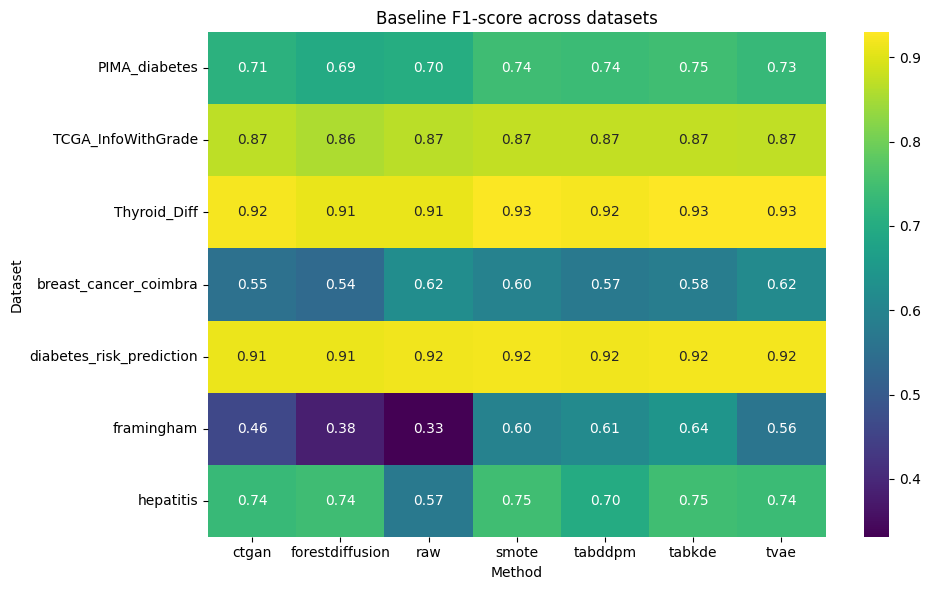

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


heatmap_data = (baseline_summary.groupby(["Dataset", "Method"])["G_mean"].mean().unstack())
plt.figure(figsize=(10,6))

sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.title("Baseline F1-score across datasets")
plt.tight_layout()
plt.show()

### 2. 主消融实验

In [12]:
import pandas as pd
from scipy import stats
from evaluation.inner_dataset_analysis import (
    validate_and_prepare, parse_ifc_cells, art_anova_3x2, friedman_nemenyi,
    IFC_CELLS
)

metric = "G_mean"   # 后面同样跑一遍 metric="G_mean"

main_df = all_results[
    all_results["Method"].isin(IFC_CELLS) & (all_results["stage_depth"].fillna(3) == 3)].copy()

datasets = sorted(all_results["Dataset"].unique())
classifiers = sorted(all_results["Classifier"].unique())

anova_rows, rank_rows = [], []

for ds in datasets:
    df_ds = validate_and_prepare(main_df, dataset=ds)  # 校验 + 生成 block 列
    df_ds = parse_ifc_cells(df_ds)                      # 生成 prior_type / use_finetune 列

    for clf in classifiers:
        # (1) ART-ANOVA:prior_type主效应 / finetune主效应 / 交互效应 是否显著
        anova_res = art_anova_3x2(df_ds, metric, clf)
        anova_res.insert(0, "Dataset", ds)
        anova_rows.append(anova_res)

        # (2) Friedman + 平均秩:6个config在这个(数据集,分类器)下谁排第几
        fn_res = friedman_nemenyi(df_ds, metric, clf)
        r = fn_res["avg_rank"].rename("avg_rank").reset_index()
        r.columns = ["config", "avg_rank"]
        r["Dataset"], r["Classifier"] = ds, clf
        rank_rows.append(r)

anova_summary = pd.concat(anova_rows, ignore_index=True)  # 每行=(Dataset,Classifier,target_effect)
rank_long = pd.concat(rank_rows, ignore_index=True)        # 每行=(Dataset,Classifier,config)的avg_rank

In [13]:
import scikit_posthocs as sp
from scipy import stats

wide_cross = rank_long.pivot(index=["Dataset","Classifier"], columns="config", values="avg_rank")
stat, p_omnibus = stats.friedmanchisquare(*[wide_cross[c].values for c in wide_cross.columns])

nemenyi_cross = sp.posthoc_nemenyi_friedman(wide_cross.values)
nemenyi_cross.index = wide_cross.columns
nemenyi_cross.columns = wide_cross.columns

print(stat, p_omnibus)

nemenyi_cross

12.226027397260241 0.031818562710738935


config,bootstrap_ft,bootstrap_noft,none_ft,none_noft,smote_ft,smote_noft
config,,,,,,
bootstrap_ft,1.000000,0.876037,0.933763,0.510386,0.892529,0.986199
bootstrap_noft,0.876037,1.000000,0.307456,0.050594,0.244337,0.997599
none_ft,0.933763,0.307456,1.000000,0.970382,0.999996,0.592987
none_noft,0.510386,0.050594,0.970382,1.000000,0.986199,0.158946
smote_ft,0.892529,0.244337,0.999996,0.986199,1.000000,0.510386
smote_noft,0.986199,0.997599,0.592987,0.158946,0.510386,1.000000


In [14]:
cross_rank = (rank_long.groupby("config")["avg_rank"]
              .agg(mean_rank="mean", std_rank="std", n_blocks="count")
              .reset_index().sort_values("mean_rank"))

cross_rank

,config,mean_rank,std_rank,n_blocks
3,none_noft,3.224444,0.436681,21
2,none_ft,3.320317,0.451489,21
4,smote_ft,3.479048,0.282334,21
0,bootstrap_ft,3.493333,0.303857,21
5,smote_noft,3.673333,0.485606,21
1,bootstrap_noft,3.809524,0.511210,21


#### 2.2 stage2的cross_rank结果

In [15]:
stage2_cells = ["bootstrap_noft","bootstrap_ft","smote_noft","smote_ft"]

main_df_sd2 = all_results[
    all_results["Method"].isin(stage2_cells) &
    (all_results["stage_depth"] == 2)
].copy()

rank_rows_sd2 = []
for ds in datasets:
    df_ds = validate_and_prepare(main_df_sd2, dataset=ds)
    df_ds = parse_ifc_cells(df_ds)
    for clf in classifiers:
        fn_res = friedman_nemenyi(df_ds, metric, clf)
        r = fn_res["avg_rank"].rename("avg_rank").reset_index()
        r.columns = ["config", "avg_rank"]
        r["Dataset"], r["Classifier"] = ds, clf
        rank_rows_sd2.append(r)

rank_long_sd2 = pd.concat(rank_rows_sd2, ignore_index=True)
cross_rank_sd2 = (rank_long_sd2.groupby("config")["avg_rank"]
                   .agg(mean_rank="mean", std_rank="std", n_blocks="count")
                   .reset_index().sort_values("mean_rank"))

cross_rank_sd2

,config,mean_rank,std_rank,n_blocks
2,smote_ft,2.384444,0.276078,21
3,smote_noft,2.500000,0.231171,21
0,bootstrap_ft,2.520635,0.214693,21
1,bootstrap_noft,2.594921,0.264305,21


### Stage-depth消融

In [16]:
from statsmodels.stats.multitest import multipletests

sd_df = all_results[all_results["prior_type"].isin(["bootstrap","smote"])].copy()
sd_df["stage_depth"] = sd_df["stage_depth"].fillna(3)
sd_df["config"] = sd_df["prior_type"] + "_" + sd_df["finetune"].map({True: "ft", False: "noft"})
sd_df["block"] = sd_df["Seed"].astype(str) + "_" + sd_df["Fold"].astype(str)


rows = []
for ds in datasets:
    for clf in classifiers:
        sub = sd_df[(sd_df["Dataset"] == ds) & (sd_df["Classifier"] == clf)]
        for cfg in ["bootstrap_noft", "bootstrap_ft", "smote_noft", "smote_ft"]:
            wide = sub[sub["config"] == cfg].pivot(index="block", columns="stage_depth", values="G_mean")
            if wide.shape[1] < 2 or wide.isna().any().any():
                continue  # 这个(数据集,分类器,config)覆盖不全,跳过——不要悄悄当无差异处理
            stat, p = stats.wilcoxon(wide[3], wide[2])
            rows.append({"Dataset": ds, "Classifier": clf, "config": cfg,
                          "median_diff_sd3_minus_sd2": (wide[3] - wide[2]).median(),
                          "p_unc": p})
sd_block_results = pd.DataFrame(rows)


final_rows = []
for cfg, g in sd_block_results.groupby("config"):
    stat, p = stats.wilcoxon(g["median_diff_sd3_minus_sd2"])
    final_rows.append({"config": cfg, "n_blocks": len(g),
                        "median_of_diffs": g["median_diff_sd3_minus_sd2"].median(), "p_unc": p})
sd_summary = pd.DataFrame(final_rows)
sd_summary["p_holm"] = multipletests(sd_summary["p_unc"], method="holm")[1]

sd_summary

,config,n_blocks,median_of_diffs,p_unc,p_holm
0,bootstrap_ft,21,0.0,0.239317,0.478633
1,bootstrap_noft,21,0.0,0.398025,0.478633
2,smote_ft,21,0.0,0.035692,0.107076
3,smote_noft,21,0.0,0.020879,0.083517


In [17]:
diag_rows = []
for cfg, g in sd_block_results.groupby("config"):
    diag_rows.append({
        "config": cfg,
        "n_blocks": len(g),
        "n_positive": (g["median_diff_sd3_minus_sd2"] > 0).sum(),
        "n_negative": (g["median_diff_sd3_minus_sd2"] < 0).sum(),
        "n_zero": (g["median_diff_sd3_minus_sd2"] == 0).sum(),
    })
pd.DataFrame(diag_rows)

,config,n_blocks,n_positive,n_negative,n_zero
0,bootstrap_ft,21,7,5,9
1,bootstrap_noft,21,2,5,14
2,smote_ft,21,2,6,13
3,smote_noft,21,2,7,12


### Mix_ratio 敏感性

In [18]:
# 如果两套mix_ratio结果还在各自独立的文件里,先加标签再合并
from process.utils import get_mix_ratio_results

root = Path.cwd().parent
df_37 = get_mix_ratio_results(root/'mix_ratio'/'mix_37_235')
df_37["mix_ratio_config"] = "mix_37_235"
df_55 = get_mix_ratio_results(root/'mix_ratio'/'mix_55_532')
df_55["mix_ratio_config"] = "mix_55_532"

mix_df_raw = pd.concat([df_37, df_55], ignore_index=True)

coverage = (mix_df_raw[mix_df_raw["prior_type"].isin(["bootstrap","smote"])]
            .groupby(["prior_type","finetune","mix_ratio_config"])["Dataset"]
            .nunique())
print(coverage)

prior_type  finetune  mix_ratio_config
bootstrap   False     mix_37_235          7
                      mix_55_532          7
            True      mix_37_235          7
                      mix_55_532          7
smote       False     mix_37_235          7
                      mix_55_532          7
            True      mix_37_235          7
                      mix_55_532          7
Name: Dataset, dtype: int64


In [19]:
mix_df = mix_df_raw[
    mix_df_raw["prior_type"].isin(["bootstrap","smote"]) &
    (mix_df_raw["stage_depth"].fillna(3) == 3)   # 显式锁定stage3,不再涉及stage-depth维度
].copy()

mix_df["config"] = mix_df["prior_type"] + "_" + mix_df["finetune"].map({True: "ft", False: "noft"})
mix_df["block"] = mix_df["Seed"].astype(str) + "_" + mix_df["Fold"].astype(str)

rows = []
for ds in datasets:
    for clf in classifiers:
        sub = mix_df[(mix_df["Dataset"] == ds) & (mix_df["Classifier"] == clf)]
        for cfg in ["none_noft", "none_ft", "bootstrap_noft", "bootstrap_ft", "smote_noft", "smote_ft"]:
            wide = sub[sub["config"] == cfg].pivot(index="block", columns="mix_ratio_config", values="G_mean")
            if not {"mix_37_235", "mix_55_532"}.issubset(wide.columns) or wide[["mix_37_235","mix_55_532"]].isna().any().any():
                continue
            stat, p = stats.wilcoxon(wide["mix_55_532"], wide["mix_37_235"])
            rows.append({"Dataset": ds, "Classifier": clf, "config": cfg,
                          "median_diff_5532_minus_3723": (wide["mix_55_532"] - wide["mix_37_235"]).median(),
                          "p_unc": p})
mix_block_results = pd.DataFrame(rows)

final_rows = []
for cfg, g in mix_block_results.groupby("config"):
    stat, p = stats.wilcoxon(g["median_diff_5532_minus_3723"])
    final_rows.append({"config": cfg, "n_blocks": len(g),
                        "median_of_diffs": g["median_diff_5532_minus_3723"].median(), "p_unc": p})
mix_summary = pd.DataFrame(final_rows)
mix_summary["p_holm"] = multipletests(mix_summary["p_unc"], method="holm")[1]

mix_summary

,config,n_blocks,median_of_diffs,p_unc,p_holm
0,bootstrap_ft,21,0.0,0.878482,0.878482
1,bootstrap_noft,21,0.0,0.012515,0.037546
2,smote_ft,21,0.0,0.007686,0.030743
3,smote_noft,21,0.0,0.284503,0.569005


In [27]:
for cfg, g in mix_block_results.groupby("config"):
    print(cfg,
          "55_532更优的block数=", (g["median_diff_5532_minus_3723"] > 0).sum(),
          "37_235更优的block数=", (g["median_diff_5532_minus_3723"] < 0).sum())

bootstrap_ft 55_532更优的block数= 5 37_235更优的block数= 5
bootstrap_noft 55_532更优的block数= 9 37_235更优的block数= 1
smote_ft 55_532更优的block数= 9 37_235更优的block数= 0
smote_noft 55_532更优的block数= 6 37_235更优的block数= 4


In [21]:
overall_stat, overall_p = stats.wilcoxon(mix_block_results["median_diff_5532_minus_3723"])
print(f"整体(4个config合并, n={len(mix_block_results)}): stat={overall_stat}, p={overall_p}")

整体(4个config合并, n=84): stat=197.0, p=0.007074547978309022


In [20]:
def build_depth_trend(all_results, config_label, metric):
    """config_label: 'smote_noft' 或 'smote_ft'"""
    d1 = all_results[all_results["Method"] == "smote"][
        ["Dataset","Classifier","Seed","Fold",metric]
    ].rename(columns={metric: "d1"})

    d2 = all_results[
        (all_results["Method"] == config_label) & (all_results["stage_depth"] == 2)
    ][["Dataset","Classifier","Seed","Fold",metric]].rename(columns={metric: "d2"})

    d3 = all_results[
        (all_results["Method"] == config_label) & (all_results["stage_depth"].fillna(3) == 3)
    ][["Dataset","Classifier","Seed","Fold",metric]].rename(columns={metric: "d3"})

    trend_df = d1.merge(d2, on=["Dataset","Classifier","Seed","Fold"]) \
                 .merge(d3, on=["Dataset","Classifier","Seed","Fold"])
    return trend_df


from scipy.stats import page_trend_test

metric = 'F1_score'

for cfg in ["smote_noft", "smote_ft"]:
    trend_df = build_depth_trend(all_results, cfg, metric)  # metric = "F1_score" 或 "G_mean"
    # 先在(Dataset,Classifier)区组内对Seed×Fold取均值,得到 n_blocks × 3(depth) 的矩阵
    per_block = trend_df.groupby(["Dataset","Classifier"])[["d1","d2","d3"]].mean().reset_index()

    res = page_trend_test(per_block[["d1","d2","d3"]].values, predicted_ranks=[1, 2, 3])
    print(cfg, "L统计量=", res.statistic, "p=", res.pvalue)

smote_noft L统计量= 225.0 p= 0.999984513401138
smote_ft L统计量= 228.0 p= 0.9998935852904928


In [28]:
# (a) 直接看三个depth的均值走向,最直观
for cfg in ["smote_noft", "smote_ft"]:
    trend_df = build_depth_trend(all_results, cfg, metric)
    per_block = trend_df.groupby(["Dataset","Classifier"])[["d1","d2","d3"]].mean().reset_index()
    print(cfg, per_block[["d1","d2","d3"]].mean().to_dict())

# (b) 反过来检验"递减"假设,应该会得到很小的p值,和上面的结果互为印证
from scipy.stats import page_trend_test
for cfg in ["smote_noft", "smote_ft"]:
    trend_df = build_depth_trend(all_results, cfg, metric)
    per_block = trend_df.groupby(["Dataset","Classifier"])[["d1","d2","d3"]].mean().reset_index()
    res_dec = page_trend_test(per_block[["d1","d2","d3"]].values, predicted_ranks=[3, 2, 1])
    print(cfg, "递减假设 p=", res_dec.pvalue)

smote_noft {'d1': 0.716000938568365, 'd2': 0.705404040717148, 'd3': 0.701709864106771}
smote_ft {'d1': 0.716000938568365, 'd2': 0.7083680697853596, 'd3': 0.7042414450251882}
smote_noft 递减假设 p= 1.548659886197278e-05
smote_ft 递减假设 p= 0.00010641470950718837


In [26]:
def slice_by_dataset(long_table, dataset_name, value_col):
    sub = long_table[long_table["Dataset"] == dataset_name]
    return (sub.groupby("config")[value_col]
            .agg(mean_val="mean", std_val="std", n="count")
            .reset_index().sort_values("mean_val"))

slice_by_dataset(rank_long, "hepatitis", "avg_rank")   # 举例:只看FRM数据集内6个config的排名

,config,mean_val,std_val,n
3,none_noft,3.255556,0.335548,3
2,none_ft,3.344444,0.637995,3
0,bootstrap_ft,3.422222,0.134715,3
4,smote_ft,3.444444,0.401848,3
1,bootstrap_noft,3.744444,0.582460,3
5,smote_noft,3.788889,0.371683,3
